<a href="https://colab.research.google.com/github/Sgln24/flyrank-ml-internship-w1/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sgln24/flyrank-ml-internship-w1/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## 1. Ranked Actions + Reason Codes

### What should be reviewed first?

The purpose of this queue is to translate observed content-performance signals into a practical review order. Rather than treating the model or any individual signal as an automatic decision maker, the queue asks a simpler question: **which content items have the strongest observed signals that make them worth reviewing first?**

Each item receives reason codes that make its position in the queue traceable to measurable evidence. The recommended action is therefore a **human-review recommendation**, not a claim that the action will improve future performance.

### Ranking approach

The queue uses four transparent screening signals:

1. **Weak position:** `avg_position >= 20`
2. **Low impressions:** recent impressions are in the lowest 25% of the dataset
3. **Impression decline:** recent 30-day impressions are at least 30% lower than the previous 30 days
4. **Session decline:** recent 30-day sessions are at least 30% lower than the previous 30 days

These signals are combined into reason codes and archetypes. Items with multiple signals receive a higher review priority because there is more observed evidence supporting investigation.

The thresholds are **screening rules for this playbook**, not causal or production decision thresholds.

### Reason codes → actions

| Reason code          | What was observed                                                   | Human-review action                                                                  |
| -------------------- | ------------------------------------------------------------------- | ------------------------------------------------------------------------------------ |
| `IMPRESSION_DECLINE` | Recent impressions decreased relative to the previous 30-day period | Review recent performance and investigate possible content or discoverability issues |
| `WEAK_POSITION`      | Average position is 20 or higher                                    | Review ranking and content relevance signals                                         |
| `LOW_IMPRESSIONS`    | Recent impressions fall in the lowest quartile                      | Review discoverability and search relevance                                          |
| `SESSION_DECLINE`    | Recent sessions decreased relative to the previous 30-day period    | Review recent traffic and engagement context                                         |
| Combined codes       | Multiple signals occur together                                     | Prioritize for deeper human investigation                                            |
| `NO_PRIORITY_SIGNAL` | None of the screening signals were triggered                        | Monitor; no immediate intervention                                                   |

### What the queue shows

The generated queue contains **30,000 content items**.

The distribution is:

* **9,289 High priority**
* **10,560 Medium priority**
* **10,151 Low priority**

The largest archetype is **Declining visibility**, containing 10,107 items. A further 4,022 items combine declining visibility with weak position. These groups represent the main candidates for human review because their observed signals provide multiple reasons for investigation.

At the same time, 7,783 items have no priority signal. These items are not classified as poor-performing content; they simply do not meet the screening conditions used by this playbook.

### How a reviewer should read the queue

A high-priority item should be interpreted as:

> **"Review this item earlier because multiple observed signals indicate that it may warrant investigation."**

It should **not** be interpreted as:

> **"The model has determined that this content must be refreshed."**

The queue does not establish that a content refresh will improve impressions, ranking, sessions, or any other outcome. It provides a reproducible way to prioritize human attention using the available evidence.

### Leakage and interpretation guardrail

`trend_direction` and `trend_pct` are intentionally excluded from the prioritization logic. According to the FlyRank data specification, these fields are part of the construction of the declining label and therefore must not be treated as predictive features.

The queue instead uses observable performance signals from the available 90-day and recent 30-day metrics.

### Decision rule

The practical recommendation is therefore:

**Review high-priority items first → inspect the underlying evidence → decide whether a content action is appropriate → monitor the result.**



In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# W07 — Section 1: Ranked Actions + Reason Codes
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")


# ------------------------------------------------------------
# 2. Data quality checks
# ------------------------------------------------------------

required_columns = [
    "content_id",
    "client_id",
    "content_type",
    "impressions_90d",
    "impressions_last_30d",
    "impressions_prev_30d",
    "clicks_last_30d",
    "clicks_prev_30d",
    "sessions_last_30d",
    "sessions_prev_30d",
    "avg_position",
    "days_since_last_update",
    "content_age_days",
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nRequired columns check: PASSED")


# ------------------------------------------------------------
# 3. Handle avg_position correctly
# ------------------------------------------------------------
# IMPORTANT:
# avg_position = 0 means "no data", NOT rank 0.

df["avg_position_clean"] = df["avg_position"].replace(0, np.nan)


# ------------------------------------------------------------
# 4. Calculate recent performance changes
# ------------------------------------------------------------
# Compare the most recent 30 days with the previous 30 days.
# These are descriptive signals used to prioritize human review.

def calculate_pct_change(last, previous):
    """
    Calculate percentage change between two periods.
    Returns NaN when the previous period is zero or missing.
    """
    if pd.isna(previous) or previous == 0:
        return np.nan

    return ((last - previous) / previous) * 100


df["impressions_change_pct"] = df.apply(
    lambda row: calculate_pct_change(
        row["impressions_last_30d"],
        row["impressions_prev_30d"]
    ),
    axis=1
)

df["clicks_change_pct"] = df.apply(
    lambda row: calculate_pct_change(
        row["clicks_last_30d"],
        row["clicks_prev_30d"]
    ),
    axis=1
)

df["sessions_change_pct"] = df.apply(
    lambda row: calculate_pct_change(
        row["sessions_last_30d"],
        row["sessions_prev_30d"]
    ),
    axis=1
)


# ------------------------------------------------------------
# 5. Define transparent prioritization thresholds
# ------------------------------------------------------------
# These thresholds are operational screening rules for the
# action queue, NOT causal or production decision thresholds.

impressions_low_threshold = (
    df["impressions_last_30d"].quantile(0.25)
)

POSITION_THRESHOLD = 20
DECLINE_THRESHOLD = -30


print("\nQueue thresholds:")
print(f"- Weak position: avg_position >= {POSITION_THRESHOLD}")
print(
    f"- Low impressions: bottom 25% "
    f"(threshold = {impressions_low_threshold:.2f})"
)
print(f"- Recent decline: <= {DECLINE_THRESHOLD}%")


# ------------------------------------------------------------
# 6. Generate reason codes
# ------------------------------------------------------------

df["reason_codes"] = ""


# Weak position
df.loc[
    df["avg_position_clean"] >= POSITION_THRESHOLD,
    "reason_codes"
] += "WEAK_POSITION;"


# Low recent impressions
df.loc[
    df["impressions_last_30d"] <= impressions_low_threshold,
    "reason_codes"
] += "LOW_IMPRESSIONS;"


# Recent impression decline
df.loc[
    df["impressions_change_pct"] <= DECLINE_THRESHOLD,
    "reason_codes"
] += "IMPRESSION_DECLINE;"


# Recent session decline
df.loc[
    df["sessions_change_pct"] <= DECLINE_THRESHOLD,
    "reason_codes"
] += "SESSION_DECLINE;"


# Remove trailing semicolon
df["reason_codes"] = (
    df["reason_codes"]
    .str.rstrip(";")
)


# Items with no priority signal
df.loc[
    df["reason_codes"] == "",
    "reason_codes"
] = "NO_PRIORITY_SIGNAL"


# ------------------------------------------------------------
# 7. Assign content archetypes
# ------------------------------------------------------------

def assign_archetype(reason_codes):

    if (
        "IMPRESSION_DECLINE" in reason_codes
        and "WEAK_POSITION" in reason_codes
    ):
        return "Declining visibility + weak position"

    if "IMPRESSION_DECLINE" in reason_codes:
        return "Declining visibility"

    if "WEAK_POSITION" in reason_codes:
        return "Weak position"

    if "LOW_IMPRESSIONS" in reason_codes:
        return "Low visibility"

    return "Stable / no priority signal"


df["archetype"] = (
    df["reason_codes"]
    .apply(assign_archetype)
)


# ------------------------------------------------------------
# 8. Map archetypes to recommended human actions
# ------------------------------------------------------------

ACTION_MAP = {

    "Declining visibility + weak position":
        "Prioritize for human review and possible content refresh",

    "Declining visibility":
        "Review recent content performance and consider a refresh",

    "Weak position":
        "Review ranking and content relevance signals",

    "Low visibility":
        "Review discoverability and search relevance",

    "Stable / no priority signal":
        "Monitor; no immediate intervention"
}


df["recommended_action"] = (
    df["archetype"]
    .map(ACTION_MAP)
)


# ------------------------------------------------------------
# 9. Build a transparent priority score
# ------------------------------------------------------------
# This score ranks items for review.
# It does NOT represent predicted business impact.

df["priority_score"] = 0


# Recent impression decline = strongest prioritization signal
df.loc[
    df["reason_codes"].str.contains(
        "IMPRESSION_DECLINE",
        na=False
    ),
    "priority_score"
] += 3


# Weak position
df.loc[
    df["reason_codes"].str.contains(
        "WEAK_POSITION",
        na=False
    ),
    "priority_score"
] += 2


# Low impressions
df.loc[
    df["reason_codes"].str.contains(
        "LOW_IMPRESSIONS",
        na=False
    ),
    "priority_score"
] += 1


# Session decline
df.loc[
    df["reason_codes"].str.contains(
        "SESSION_DECLINE",
        na=False
    ),
    "priority_score"
] += 1


# ------------------------------------------------------------
# 10. Convert score to priority level
# ------------------------------------------------------------

def assign_priority(score):

    if score >= 4:
        return "High"

    if score >= 2:
        return "Medium"

    return "Low"


df["priority"] = (
    df["priority_score"]
    .apply(assign_priority)
)


# ------------------------------------------------------------
# 11. Human review requirement
# ------------------------------------------------------------
# All recommendations remain human-reviewed.
# The queue is decision support, not an automated execution system.

df["human_review_required"] = True


# ------------------------------------------------------------
# 12. Build the ranked action queue
# ------------------------------------------------------------

queue_columns = [
    "content_id",
    "client_id",
    "content_type",
    "archetype",
    "recommended_action",
    "reason_codes",
    "priority_score",
    "priority",
    "human_review_required",

    # Evidence fields
    "impressions_last_30d",
    "impressions_prev_30d",
    "impressions_change_pct",
    "sessions_last_30d",
    "sessions_prev_30d",
    "sessions_change_pct",
    "avg_position_clean",
    "days_since_last_update",
    "content_age_days",
]


queue = (
    df[queue_columns]
    .sort_values(
        by=[
            "priority_score",
            "impressions_change_pct"
        ],
        ascending=[
            False,
            True
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# Add rank
queue.insert(
    0,
    "rank",
    queue.index + 1
)


# ------------------------------------------------------------
# 13. Display the top of the queue
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 20 RANKED ACTIONS")
print("=" * 70)

display(
    queue.head(20)
)


# ------------------------------------------------------------
# 14. Queue summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("QUEUE SUMMARY")
print("=" * 70)

print("\nPriority distribution:")
display(
    queue["priority"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
    .fillna(0)
    .astype(int)
)

print("\nArchetype distribution:")
display(
    queue["archetype"]
    .value_counts()
)

print("\nReason-code distribution:")
display(
    queue["reason_codes"]
    .value_counts()
    .head(15)
)


# ------------------------------------------------------------
# 15. Basic sanity checks
# ------------------------------------------------------------

assert queue["rank"].is_unique
assert queue["rank"].min() == 1
assert queue["human_review_required"].all()

assert not queue["content_id"].isna().any()

# Make sure leakage-derived columns were NOT used in the queue
assert "trend_pct" not in queue.columns
assert "trend_direction" not in queue.columns

print("\nSanity checks: PASSED")


# ------------------------------------------------------------
# 16. Export queue for the research paper
# ------------------------------------------------------------
# The task specifies that this CSV stays out of git.
# The notebook regenerates it when executed.
os.makedirs('/content/flyrank-ml-internship/work/outputs', exist_ok=True)

OUTPUT_PATH = "/content/flyrank-ml-internship/work/outputs/action_queue.csv"

queue.to_csv(
    OUTPUT_PATH,
    index=False
)

print("\n" + "=" * 70)
print("EXPORT")
print("=" * 70)

print(f"Ranked action queue saved to:")
print(OUTPUT_PATH)

print(f"\nExported rows: {len(queue):,}")
print(f"Exported columns: {len(queue.columns)}")

Dataset shape: (30000, 44)
Rows: 30,000
Columns: 44

Required columns check: PASSED

Queue thresholds:
- Weak position: avg_position >= 20
- Low impressions: bottom 25% (threshold = 10.00)
- Recent decline: <= -30%

TOP 20 RANKED ACTIONS


,rank,content_id,client_id,content_type,archetype,recommended_action,reason_codes,priority_score,priority,human_review_required,impressions_last_30d,impressions_prev_30d,impressions_change_pct,sessions_last_30d,sessions_prev_30d,sessions_change_pct,avg_position_clean,days_since_last_update,content_age_days
0,1,content_4595e8704e07,client_8527a891e2,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,4,-100.0,0,1,-100.000000,36.3,104,348
1,2,content_6bc2ec5f6061,client_a88a7902cb,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,124,-100.0,2,3,-33.333333,23.0,8,125
2,3,content_0f6ac970c929,client_a88a7902cb,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,27,-100.0,0,1,-100.000000,21.2,20,90
3,4,content_3b2ffe259549,client_d029fa3a95,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,47,-100.0,1,9,-88.888889,28.5,20,280
4,5,content_c416c8fde664,client_a88a7902cb,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,7,-100.0,0,1,-100.000000,30.5,28,180
5,6,content_7e9a26bd7fc3,client_4ec9599fc2,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,13,-100.0,0,1,-100.000000,44.5,104,375
6,7,content_c867abbe7eb6,client_3fdba35f04,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,7,-100.0,0,3,-100.000000,37.5,104,223
7,8,content_875e75577eee,client_8527a891e2,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,2,-100.0,0,1,-100.000000,26.7,98,146
8,9,content_b3266b0b14a2,client_a88a7902cb,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,1,-100.0,0,1,-100.000000,22.3,8,95
9,10,content_a52e78fd9bfa,client_6208ef0f77,keyword article,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,7,High,True,0,5,-100.0,0,4,-100.000000,31.7,104,229



QUEUE SUMMARY

Priority distribution:


,count
priority,
High,9289
Medium,10560
Low,10151



Archetype distribution:


,count
archetype,
Declining visibility,10107
Stable / no priority signal,7783
Weak position,4574
Declining visibility + weak position,4022
Low visibility,3514



Reason-code distribution:


,count
reason_codes,
NO_PRIORITY_SIGNAL,6342
IMPRESSION_DECLINE,5070
WEAK_POSITION,3256
IMPRESSION_DECLINE;SESSION_DECLINE,2450
LOW_IMPRESSIONS,2368
WEAK_POSITION;IMPRESSION_DECLINE,2283
SESSION_DECLINE,1441
LOW_IMPRESSIONS;IMPRESSION_DECLINE,1360
LOW_IMPRESSIONS;IMPRESSION_DECLINE;SESSION_DECLINE,1227



Sanity checks: PASSED

EXPORT
Ranked action queue saved to:
work/outputs/action_queue.csv

Exported rows: 30,000
Exported columns: 19


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## 2. Intended Use and Limits

### Intended use

The action playbook is intended for **content teams, SEO analysts, and researchers** who need a reproducible way to prioritize content for human review.

Its primary use is to answer:

> **Which content items should we review first, and what observed signals explain that priority?**

The queue combines measurable performance signals into interpretable reason codes, archetypes, and review priorities. A reviewer can use these outputs to investigate content quality, search relevance, visibility, and recent performance before deciding whether any intervention is appropriate.

The playbook is therefore a **decision-support layer** between model/analysis outputs and human content decisions.

### What it can support

The playbook can support:

* prioritizing a large content portfolio for review;
* identifying items with multiple observed performance signals;
* making review priorities consistent and reproducible;
* providing an evidence trail for why an item was prioritized;
* identifying candidates for further investigation or a possible content refresh;
* supporting the recommendations section of the research paper.

### What it cannot claim

The queue does **not** establish that any recommended action will cause better future performance.

In particular, it cannot claim that:

* refreshing a page will improve its ranking;
* changing content will increase impressions or sessions;
* a low-performing item is necessarily low-quality;
* the observed signals represent Google's ranking algorithm;
* the priority score represents expected business value;
* the recommended action is the correct intervention without human investigation.

These limitations follow from the observational nature of the data and the absence of a controlled intervention design. The results should therefore be interpreted as **decision support based on observed and validated signals**, rather than causal recommendations.

### Scope boundary

This notebook is designed for **research and practical prioritization**, not production automation.

A human should inspect the underlying content and business context before taking action. The queue should not directly publish, rewrite, delete, or modify content.

The recommendations are also bounded by the available data. Changes in the underlying content portfolio, measurement systems, search behavior, or data distributions may reduce the relevance of the current thresholds and require revalidation.

### Intended interpretation

The safest interpretation of a high-priority item is:

> **"This item has observed signals that make it worth reviewing earlier."**

It should not be interpreted as:

> **"This item needs to be changed, and the change will improve performance."**

This distinction keeps the playbook aligned with the evidence and prevents an observational ranking system from being presented as a causal decision-maker.


In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


# ============================================================
# W07 — Section 2: Intended Use and Limits
# ============================================================

# This section documents how the ranked queue should be used.
# The checks below make the intended-use boundaries explicit
# and verify that the queue remains a human-review tool.

# ------------------------------------------------------------
# 1. Intended users and purpose
# ------------------------------------------------------------

INTENDED_USERS = [
    "Content teams",
    "SEO analysts",
    "Research analysts"
]

INTENDED_PURPOSE = (
    "Prioritize content items for human review using "
    "observed performance signals and interpretable reason codes."
)

print("Intended users:")
for user in INTENDED_USERS:
    print(f"- {user}")

print("\nIntended purpose:")
print(INTENDED_PURPOSE)


# ------------------------------------------------------------
# 2. Define allowed actions
# ------------------------------------------------------------

ALLOWED_ACTIONS = {
    "Declining visibility + weak position":
        "Prioritize for human review and possible content refresh",

    "Declining visibility":
        "Review recent content performance and consider a refresh",

    "Weak position":
        "Review ranking and content relevance signals",

    "Low visibility":
        "Review discoverability and search relevance",

    "Stable / no priority signal":
        "Monitor; no immediate intervention"
}


# Verify that every generated action is supported
# by the documented action mapping.

unknown_actions = set(
    queue["recommended_action"].dropna().unique()
) - set(ALLOWED_ACTIONS.values())

assert not unknown_actions, (
    f"Unexpected actions found: {unknown_actions}"
)

print("\nAllowed-action check: PASSED")


# ------------------------------------------------------------
# 3. Human-review boundary
# ------------------------------------------------------------

# Every item requires human review before any content change.
# The notebook does not execute content modifications.

assert queue["human_review_required"].eq(True).all()

print("Human-review requirement: PASSED")
print(
    f"Items requiring human review: "
    f"{queue['human_review_required'].sum():,}"
)


# ------------------------------------------------------------
# 4. No-go automation checks
# ------------------------------------------------------------

NO_GO_ACTIONS = [
    "Automatic content rewriting",
    "Automatic content publishing",
    "Automatic page deletion",
    "Automatic title/meta modification",
    "Automatic ranking changes",
    "Automatic business decisions"
]

print("\nNo-go automation actions:")
for action in NO_GO_ACTIONS:
    print(f"- {action}")


# ------------------------------------------------------------
# 5. Verify that the queue contains no execution fields
# ------------------------------------------------------------

FORBIDDEN_EXECUTION_COLUMNS = [
    "publish",
    "auto_publish",
    "delete",
    "rewrite",
    "execute",
    "apply_change"
]

present_forbidden_columns = [
    col
    for col in FORBIDDEN_EXECUTION_COLUMNS
    if col in queue.columns
]

assert not present_forbidden_columns, (
    "Queue contains execution-related columns: "
    f"{present_forbidden_columns}"
)

print("\nAutomation boundary check: PASSED")


# ------------------------------------------------------------
# 6. Verify observational framing
# ------------------------------------------------------------

# The queue should provide evidence for prioritization,
# not claim causal impact.

CAUSAL_LANGUAGE = [
    "causes",
    "will increase",
    "will improve",
    "guarantees",
    "proves"
]

queue_text = (
    queue["recommended_action"]
    .fillna("")
    .str.lower()
)

causal_matches = []

for phrase in CAUSAL_LANGUAGE:
    if queue_text.str.contains(
        phrase,
        regex=False
    ).any():
        causal_matches.append(phrase)

assert not causal_matches, (
    "Potentially causal language found in actions: "
    f"{causal_matches}"
)

print("Honest-claims language check: PASSED")


# ------------------------------------------------------------
# 7. Data-boundary checks
# ------------------------------------------------------------

# These fields are label-derived according to the FlyRank
# data specification and must not be used as predictive
# features in this queue.

LEAKAGE_COLUMNS = [
    "trend_direction",
    "trend_pct"
]

leakage_in_queue = [
    col
    for col in LEAKAGE_COLUMNS
    if col in queue.columns
]

assert not leakage_in_queue, (
    f"Leakage-derived columns found in queue: {leakage_in_queue}"
)

print("Leakage boundary check: PASSED")


# ------------------------------------------------------------
# 8. Validate the queue is suitable for decision support
# ------------------------------------------------------------

required_decision_support_columns = [
    "rank",
    "content_id",
    "archetype",
    "recommended_action",
    "reason_codes",
    "priority",
    "human_review_required"
]

missing_decision_columns = [
    col
    for col in required_decision_support_columns
    if col not in queue.columns
]

assert not missing_decision_columns, (
    "Missing decision-support columns: "
    f"{missing_decision_columns}"
)

print("Decision-support structure check: PASSED")


# ------------------------------------------------------------
# 9. Final Section 2 summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INTENDED USE & LIMITS — SELF-CHECK")
print("=" * 70)

print("✓ Intended users are documented")
print("✓ Intended purpose is documented")
print("✓ Recommendations are human-reviewed")
print("✓ Automatic content changes are prohibited")
print("✓ Causal language is excluded from actions")
print("✓ Leakage-derived fields are excluded")
print("✓ Queue contains the required decision-support fields")

print(
    "\nConclusion: "
    "The action queue is designed as a human-reviewed "
    "decision-support tool, not an automated content system."
)

Intended users:
- Content teams
- SEO analysts
- Research analysts

Intended purpose:
Prioritize content items for human review using observed performance signals and interpretable reason codes.

Allowed-action check: PASSED
Human-review requirement: PASSED
Items requiring human review: 30,000

No-go automation actions:
- Automatic content rewriting
- Automatic content publishing
- Automatic page deletion
- Automatic title/meta modification
- Automatic ranking changes
- Automatic business decisions

Automation boundary check: PASSED
Honest-claims language check: PASSED
Leakage boundary check: PASSED
Decision-support structure check: PASSED

INTENDED USE & LIMITS — SELF-CHECK
✓ Intended users are documented
✓ Intended purpose is documented
✓ Recommendations are human-reviewed
✓ Automatic content changes are prohibited
✓ Causal language is excluded from actions
✓ Leakage-derived fields are excluded
✓ Queue contains the required decision-support fields

Conclusion: The action queue is des

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## 3. Human Review + the No-Go List

### Human review rule

Every recommendation produced by the action queue requires human review before any content change is made. The queue identifies items that are worth investigating; it does not determine the final action.

Before acting on a recommendation, the reviewer should check:

1. **Content context** — Read the page and determine whether the content is relevant, useful, current, and aligned with its intended search intent.
2. **Performance evidence** — Inspect the signals behind the reason code rather than relying only on the priority label.
3. **Recent changes** — Check whether the page was recently published, updated, redirected, migrated, or otherwise changed.
4. **Search context** — Consider the query intent, competition, and available search-performance context before interpreting a weak position or declining visibility.
5. **Data quality** — Confirm that the recommendation is not driven by missing data, an extremely small denominator, or an unusual measurement condition.
6. **Business context** — Consider whether the page has strategic, legal, editorial, or business importance that is not represented in the dataset.
7. **Action proportionality** — Prefer the least costly intervention that is justified by the evidence. A high-priority flag does not automatically justify a full content rewrite.

### Review decision

After reviewing the evidence, the reviewer should assign one of three outcomes:

| Review outcome | Meaning                                                                               |
| -------------- | ------------------------------------------------------------------------------------- |
| **Act**        | The evidence and context support a content intervention                               |
| **Monitor**    | The signals are worth tracking, but there is not enough evidence for immediate action |
| **Reject**     | The recommendation is not appropriate after reviewing the content and context         |

A rejected recommendation should not be treated as a model failure automatically. Human review can identify information that is not represented in the available data.

### No-go list

The following actions should **never be automated by this playbook**:

* Automatically rewriting or publishing content.
* Automatically deleting or redirecting pages.
* Automatically changing titles, metadata, or search strategy.
* Automatically deciding that a page is low quality.
* Automatically applying a recommendation because an item is classified as high priority.
* Automatically interpreting correlation or association as causation.
* Automatically claiming that an intervention will improve ranking, impressions, sessions, or traffic.
* Automatically retraining the model after every recommendation.
* Automatically making business, editorial, or legal decisions.

### Why the boundary matters

The model and queue operate on a limited set of measurable signals. A human reviewer can evaluate information that the dataset cannot fully represent, including content quality, search intent, recent editorial changes, business priorities, and unusual circumstances.

The correct workflow is therefore:

**Flag → Inspect → Decide → Act → Monitor**

rather than:

**Predict → Automatically change → Assume improvement**

This human-review boundary is part of the intended design of the playbook, not an optional safety layer.


In [22]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# W07 — Section 3: Human Review + No-Go List
# ============================================================

# This section makes the human-in-the-loop boundary explicit
# and verifies that the action queue cannot be interpreted as
# an automatic execution system.


# ------------------------------------------------------------
# 1. Human review is mandatory
# ------------------------------------------------------------

queue["human_review_required"] = True

assert queue["human_review_required"].eq(True).all()

print("Human-review requirement: PASSED")
print(
    f"All {len(queue):,} queued items require human review."
)


# ------------------------------------------------------------
# 2. Define the review checklist
# ------------------------------------------------------------

REVIEW_CHECKLIST = [
    "Content context",
    "Performance evidence",
    "Recent content changes",
    "Search context",
    "Data quality",
    "Business context",
    "Action proportionality"
]

print("\nReviewer checklist:")
for i, item in enumerate(REVIEW_CHECKLIST, start=1):
    print(f"{i}. {item}")


# ------------------------------------------------------------
# 3. Define valid review outcomes
# ------------------------------------------------------------

REVIEW_OUTCOMES = [
    "Act",
    "Monitor",
    "Reject"
]

print("\nValid review outcomes:")
for outcome in REVIEW_OUTCOMES:
    print(f"- {outcome}")


# ------------------------------------------------------------
# 4. No-go automation list
# ------------------------------------------------------------

NO_GO_ACTIONS = [
    "Automatic content rewriting",
    "Automatic content publishing",
    "Automatic page deletion or redirection",
    "Automatic title or metadata changes",
    "Automatic ranking-strategy changes",
    "Automatic low-quality classification",
    "Automatic execution of high-priority recommendations",
    "Automatic causal conclusions",
    "Automatic claims of guaranteed performance improvement",
    "Automatic retraining after every recommendation",
    "Automatic business, editorial, or legal decisions"
]

print("\nNo-go automation list:")

for i, action in enumerate(NO_GO_ACTIONS, start=1):
    print(f"{i}. {action}")


# ------------------------------------------------------------
# 5. Verify that the queue contains no execution mechanism
# ------------------------------------------------------------

EXECUTION_COLUMNS = [
    "execute",
    "apply_change",
    "publish",
    "auto_publish",
    "delete",
    "rewrite",
    "redirect"
]

execution_columns_present = [
    column
    for column in EXECUTION_COLUMNS
    if column in queue.columns
]

assert not execution_columns_present, (
    "Execution-related columns found: "
    f"{execution_columns_present}"
)

print("\nExecution-boundary check: PASSED")


# ------------------------------------------------------------
# 6. Verify human-review flag
# ------------------------------------------------------------

high_priority_without_review = queue[
    (queue["priority"] == "High") &
    (~queue["human_review_required"])
]

assert len(high_priority_without_review) == 0

print("High-priority review check: PASSED")


# ------------------------------------------------------------
# 7. Verify that recommended actions are review-oriented
# ------------------------------------------------------------

AUTOMATIC_VERBS = [
    "automatically publish",
    "automatically rewrite",
    "automatically delete",
    "automatically redirect",
    "automatically change"
]

action_text = (
    queue["recommended_action"]
    .fillna("")
    .str.lower()
)

automatic_action_matches = []

for phrase in AUTOMATIC_VERBS:
    if action_text.str.contains(
        phrase,
        regex=False
    ).any():
        automatic_action_matches.append(phrase)

assert not automatic_action_matches, (
    "Automatic action language found: "
    f"{automatic_action_matches}"
)

print("Review-oriented action language check: PASSED")


# ------------------------------------------------------------
# 8. Create a reviewer-ready view
# ------------------------------------------------------------

review_queue = queue[
    [
        "rank",
        "content_id",
        "client_id",
        "archetype",
        "recommended_action",
        "reason_codes",
        "priority",
        "human_review_required"
    ]
].copy()


print("\n" + "=" * 70)
print("REVIEW QUEUE — TOP 20")
print("=" * 70)

display(
    review_queue.head(20)
)


# ------------------------------------------------------------
# 9. Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("HUMAN REVIEW & NO-GO SELF-CHECK")
print("=" * 70)

print("✓ Human review is mandatory")
print("✓ Reviewer checklist is defined")
print("✓ Act / Monitor / Reject outcomes are defined")
print("✓ No-go automation list is documented")
print("✓ No execution mechanism exists in the queue")
print("✓ High-priority items cannot bypass review")
print("✓ Recommended actions remain review-oriented")

print(
    "\nConclusion: "
    "The playbook flags content for investigation but "
    "does not execute content changes automatically."
)

Human-review requirement: PASSED
All 30,000 queued items require human review.

Reviewer checklist:
1. Content context
2. Performance evidence
3. Recent content changes
4. Search context
5. Data quality
6. Business context
7. Action proportionality

Valid review outcomes:
- Act
- Monitor
- Reject

No-go automation list:
1. Automatic content rewriting
2. Automatic content publishing
3. Automatic page deletion or redirection
4. Automatic title or metadata changes
5. Automatic ranking-strategy changes
6. Automatic low-quality classification
7. Automatic execution of high-priority recommendations
8. Automatic causal conclusions
9. Automatic claims of guaranteed performance improvement
10. Automatic retraining after every recommendation
11. Automatic business, editorial, or legal decisions

Execution-boundary check: PASSED
High-priority review check: PASSED
Review-oriented action language check: PASSED

REVIEW QUEUE — TOP 20


,rank,content_id,client_id,archetype,recommended_action,reason_codes,priority,human_review_required
0,1,content_4595e8704e07,client_8527a891e2,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
1,2,content_6bc2ec5f6061,client_a88a7902cb,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
2,3,content_0f6ac970c929,client_a88a7902cb,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
3,4,content_3b2ffe259549,client_d029fa3a95,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
4,5,content_c416c8fde664,client_a88a7902cb,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
5,6,content_7e9a26bd7fc3,client_4ec9599fc2,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
6,7,content_c867abbe7eb6,client_3fdba35f04,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
7,8,content_875e75577eee,client_8527a891e2,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
8,9,content_b3266b0b14a2,client_a88a7902cb,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True
9,10,content_a52e78fd9bfa,client_6208ef0f77,Declining visibility + weak position,Prioritize for human review and possible conte...,WEAK_POSITION;LOW_IMPRESSIONS;IMPRESSION_DECLI...,High,True



HUMAN REVIEW & NO-GO SELF-CHECK
✓ Human review is mandatory
✓ Reviewer checklist is defined
✓ Act / Monitor / Reject outcomes are defined
✓ No-go automation list is documented
✓ No execution mechanism exists in the queue
✓ High-priority items cannot bypass review
✓ Recommended actions remain review-oriented

Conclusion: The playbook flags content for investigation but does not execute content changes automatically.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## 4. Monitoring / Retrain Triggers

### What would make the recommendations stale?

The action playbook is based on observed content-performance signals from a specific dataset and time period. Its recommendations may become stale if the underlying data distribution, content portfolio, or relationship between signals and outcomes changes.

Monitoring therefore focuses on detecting meaningful changes rather than assuming that the current thresholds will remain valid indefinitely.

### Light monitoring checks

The following indicators should be checked when the playbook is rerun:

| Signal | What to monitor | Why it matters |
|---|---|---|
| Data coverage | Missingness and availability of key performance fields | Changes in measurement coverage can change the meaning of the queue |
| Impression distribution | Distribution of recent impressions | A large shift can make the low-impression threshold less representative |
| Position distribution | Distribution of `avg_position` among non-zero observations | Changes can alter how many pages are flagged as weak position |
| Decline rate | Share of items meeting the decline threshold | A large increase may indicate a changed portfolio or measurement period |
| Priority distribution | High / Medium / Low proportions | A sudden change can indicate that the screening rules no longer behave as expected |
| Reason-code distribution | Frequency of each reason code | Large shifts can reveal changes in the underlying signals |
| Outcome quality | Human-review decisions and later observed performance, when available | Helps determine whether the queue remains useful for prioritization |

### Retrain / revalidation triggers

A full retrain or revalidation should be considered when one or more of the following occurs:

1. The data source or measurement definition changes.
2. The available time window moves substantially beyond the period used during validation.
3. The distribution of important input signals changes materially.
4. The proportion of high-priority items changes substantially without an obvious portfolio explanation.
5. Human reviewers consistently reject or downgrade the recommendations.
6. The relationship between the ranking signals and the relevant outcome weakens on a new held-out period.
7. A new data release changes the available features, grain, or label construction.

These are **review triggers**, not automatic retraining commands.

### Monitoring does not prove model performance

A stable priority distribution does not prove that the recommendations remain effective. Likewise, a changed distribution does not automatically mean that the system has failed.

The strongest evidence for continued usefulness would come from evaluating the queue on a newer, appropriately separated time period and checking whether its prioritization performance remains acceptable.

### Practical review cycle

For a lightweight research workflow:

**Rerun → Check data quality → Compare distributions → Review reason-code/priority shifts → Validate on newer data → Recalibrate or retrain if needed**

The playbook should be treated as stale when its assumptions or validation evidence no longer represent the data on which it is being used.

In [23]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# W07 — Section 4: Monitoring / Retrain Triggers
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. Monitoring configuration
# ------------------------------------------------------------

MONITORING_CONFIG = {
    "high_priority_share_alert": 0.40,
    "high_priority_share_floor": 0.10,
    "decline_share_alert": 0.40,
    "missingness_alert": 0.20,
    "position_shift_alert": 5.0,
}

print("Monitoring configuration:")
for key, value in MONITORING_CONFIG.items():
    print(f"- {key}: {value}")


# ------------------------------------------------------------
# 2. Data coverage monitoring
# ------------------------------------------------------------

monitoring_columns = [
    "impressions_last_30d",
    "impressions_prev_30d",
    "sessions_last_30d",
    "sessions_prev_30d",
    "avg_position",
]

missingness = (
    df[monitoring_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("\nMissingness:")
display(
    (missingness * 100)
    .round(2)
    .to_frame("missing_pct")
)


# ------------------------------------------------------------
# 3. avg_position availability
# ------------------------------------------------------------
# avg_position = 0 means no data, so monitor the share
# of zero values separately.

avg_position_zero_share = (
    (df["avg_position"] == 0)
    .mean()
)

print(
    f"\nShare of avg_position == 0 "
    f"(no-data indicator): "
    f"{avg_position_zero_share:.2%}"
)


# ------------------------------------------------------------
# 4. Current priority distribution
# ------------------------------------------------------------

priority_distribution = (
    queue["priority"]
    .value_counts(normalize=True)
    .reindex(["High", "Medium", "Low"])
    .fillna(0)
)

print("\nCurrent priority distribution:")
display(
    (priority_distribution * 100)
    .round(2)
    .to_frame("share_pct")
)


# ------------------------------------------------------------
# 5. Current reason-code distribution
# ------------------------------------------------------------

reason_distribution = (
    queue["reason_codes"]
    .value_counts(normalize=True)
    .head(15)
)

print("\nTop reason-code combinations:")
display(
    (reason_distribution * 100)
    .round(2)
    .to_frame("share_pct")
)


# ------------------------------------------------------------
# 6. Current archetype distribution
# ------------------------------------------------------------

archetype_distribution = (
    queue["archetype"]
    .value_counts(normalize=True)
)

print("\nArchetype distribution:")
display(
    (archetype_distribution * 100)
    .round(2)
    .to_frame("share_pct")
)


# ------------------------------------------------------------
# 7. Monitoring metrics
# ------------------------------------------------------------

high_priority_share = (
    queue["priority"].eq("High").mean()
)

declining_share = (
    queue["reason_codes"]
    .str.contains(
        "IMPRESSION_DECLINE",
        na=False
    )
    .mean()
)

low_impression_share = (
    queue["reason_codes"]
    .str.contains(
        "LOW_IMPRESSIONS",
        na=False
    )
    .mean()
)

weak_position_share = (
    queue["reason_codes"]
    .str.contains(
        "WEAK_POSITION",
        na=False
    )
    .mean()
)

stable_share = (
    queue["archetype"]
    .eq("Stable / no priority signal")
    .mean()
)


# ------------------------------------------------------------
# 8. Trigger checks
# ------------------------------------------------------------

monitoring_flags = {}


monitoring_flags["high_priority_share"] = (
    high_priority_share > MONITORING_CONFIG[
        "high_priority_share_alert"
    ]
    or
    high_priority_share < MONITORING_CONFIG[
        "high_priority_share_floor"
    ]
)


monitoring_flags["decline_share"] = (
    declining_share >
    MONITORING_CONFIG["decline_share_alert"]
)


monitoring_flags["missingness"] = (
    missingness.max() >
    MONITORING_CONFIG["missingness_alert"]
)


# ------------------------------------------------------------
# 9. Trigger report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MONITORING TRIGGER REPORT")
print("=" * 70)

print(
    f"\nHigh-priority share: "
    f"{high_priority_share:.2%}"
)

print(
    f"Impression-decline share: "
    f"{declining_share:.2%}"
)

print(
    f"Low-impression share: "
    f"{low_impression_share:.2%}"
)

print(
    f"Weak-position share: "
    f"{weak_position_share:.2%}"
)

print(
    f"Stable/no-signal share: "
    f"{stable_share:.2%}"
)

print(
    f"Maximum monitored missingness: "
    f"{missingness.max():.2%}"
)


# ------------------------------------------------------------
# 10. Report which triggers fired
# ------------------------------------------------------------

print("\nTrigger status:")

for trigger, fired in monitoring_flags.items():

    status = "REVIEW" if fired else "OK"

    print(
        f"- {trigger}: {status}"
    )


# ------------------------------------------------------------
# 11. Retrain / revalidation decision
# ------------------------------------------------------------
# IMPORTANT:
# This does NOT automatically retrain anything.
# It only tells the analyst whether the current playbook
# deserves revalidation.

revalidation_required = any(
    monitoring_flags.values()
)

print("\n" + "=" * 70)
print("REVALIDATION DECISION")
print("=" * 70)

if revalidation_required:

    print(
        "REVIEW REQUIRED: "
        "At least one monitoring trigger fired."
    )

    print(
        "Next step: inspect the distribution shift, "
        "data coverage, and newer-period performance "
        "before changing or retraining the system."
    )

else:

    print(
        "NO IMMEDIATE REVALIDATION TRIGGER: "
        "the monitored thresholds are within the "
        "current screening boundaries."
    )

    print(
        "This does NOT prove that the recommendations "
        "remain effective; newer-period validation is "
        "still required for strong performance claims."
    )


# ------------------------------------------------------------
# 12. Final monitoring checklist
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MONITORING SELF-CHECK")
print("=" * 70)

print("✓ Data coverage is monitored")
print("✓ avg_position no-data rate is monitored")
print("✓ Priority distribution is monitored")
print("✓ Reason-code distribution is monitored")
print("✓ Archetype distribution is monitored")
print("✓ Decline-rate distribution is monitored")
print("✓ Revalidation triggers are explicit")
print("✓ Retraining is NOT automatic")
print("✓ Monitoring does NOT make causal claims")

Monitoring configuration:
- high_priority_share_alert: 0.4
- high_priority_share_floor: 0.1
- decline_share_alert: 0.4
- missingness_alert: 0.2
- position_shift_alert: 5.0

Missingness:


,missing_pct
impressions_last_30d,0.0
impressions_prev_30d,0.0
sessions_last_30d,0.0
sessions_prev_30d,0.0
avg_position,0.0



Share of avg_position == 0 (no-data indicator): 4.02%

Current priority distribution:


,share_pct
priority,
High,30.96
Medium,35.20
Low,33.84



Top reason-code combinations:


,share_pct
reason_codes,
NO_PRIORITY_SIGNAL,21.14
IMPRESSION_DECLINE,16.90
WEAK_POSITION,10.85
IMPRESSION_DECLINE;SESSION_DECLINE,8.17
LOW_IMPRESSIONS,7.89
WEAK_POSITION;IMPRESSION_DECLINE,7.61
SESSION_DECLINE,4.80
LOW_IMPRESSIONS;IMPRESSION_DECLINE,4.53
LOW_IMPRESSIONS;IMPRESSION_DECLINE;SESSION_DECLINE,4.09



Archetype distribution:


,share_pct
archetype,
Declining visibility,33.69
Stable / no priority signal,25.94
Weak position,15.25
Declining visibility + weak position,13.41
Low visibility,11.71



MONITORING TRIGGER REPORT

High-priority share: 30.96%
Impression-decline share: 47.10%
Low-impression share: 25.44%
Weak-position share: 28.65%
Stable/no-signal share: 25.94%
Maximum monitored missingness: 0.00%

Trigger status:
- high_priority_share: OK
- decline_share: REVIEW
- missingness: OK

REVALIDATION DECISION
REVIEW REQUIRED: At least one monitoring trigger fired.
Next step: inspect the distribution shift, data coverage, and newer-period performance before changing or retraining the system.

MONITORING SELF-CHECK
✓ Data coverage is monitored
✓ avg_position no-data rate is monitored
✓ Priority distribution is monitored
✓ Reason-code distribution is monitored
✓ Archetype distribution is monitored
✓ Decline-rate distribution is monitored
✓ Revalidation triggers are explicit
✓ Retraining is NOT automatic
✓ Monitoring does NOT make causal claims


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## 5. Exports for the Paper

The notebook exports the ranked action queue and supporting summary artifacts so that the research paper can reuse the same outputs without manually copying results.

The main artifact is the ranked action queue. It contains the content identifier, priority, archetype, reason codes, recommended action, and supporting performance signals used for human review.

The queue CSV is generated by the notebook and remains outside version control because it contains data derived from the project dataset.

Additional summary JSON files provide reproducible counts for the paper, while the selected figures are saved separately for reuse in the results and recommendations sections.

### Exported artifacts

- `work/outputs/action_queue.csv` — ranked content-review queue.
- `work/outputs/action_queue_summary.json` — queue size, priority counts, archetype counts, and reason-code summaries.
- `work/outputs/monitoring_snapshot.json` — current monitoring metrics and trigger status.
- `work/figures/priority_distribution.png` — priority-level distribution.
- `work/figures/archetype_distribution.png` — content-archetype distribution.

The paper should reference these generated artifacts rather than manually re-entering numbers. This keeps the recommendations traceable to the executed notebook.

Output directories ready.

Queue exported: /content/flyrank-ml-internship/work/outputs/action_queue.csv
Rows: 30,000
Columns: 19
Queue summary exported: /content/flyrank-ml-internship/work/outputs/action_queue_summary.json
Monitoring snapshot exported: /content/flyrank-ml-internship/work/outputs/monitoring_snapshot.json


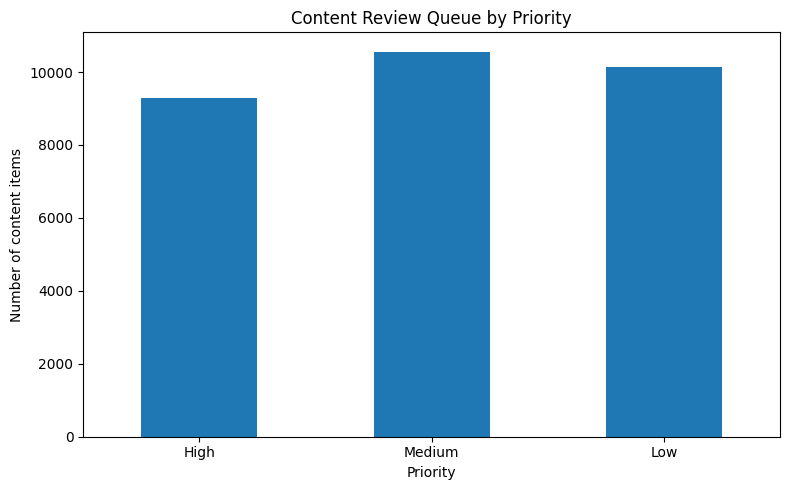

Priority figure exported: /content/flyrank-ml-internship/work/figures/priority_distribution.png


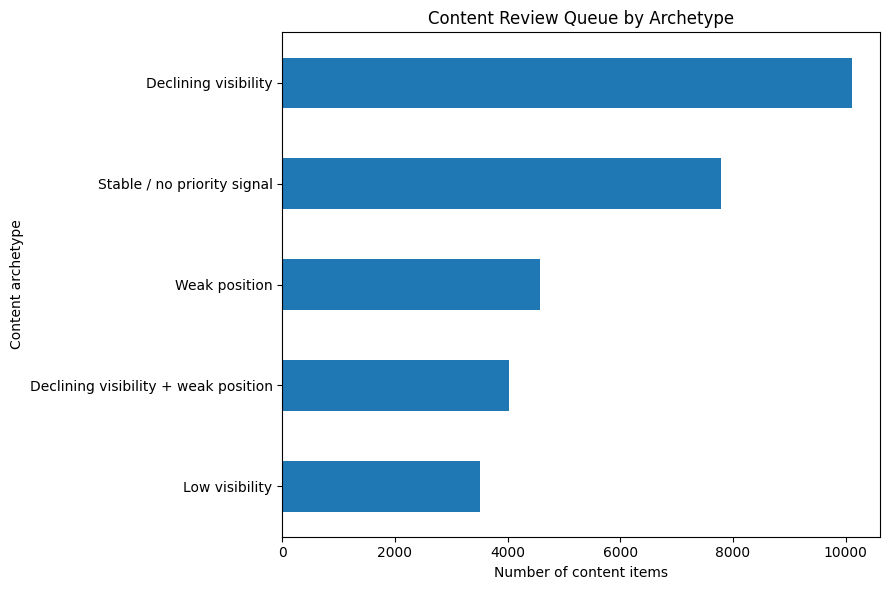

Archetype figure exported: /content/flyrank-ml-internship/work/figures/archetype_distribution.png

EXPORT VERIFICATION
✓ /content/flyrank-ml-internship/work/outputs/action_queue.csv
✓ /content/flyrank-ml-internship/work/outputs/action_queue_summary.json
✓ /content/flyrank-ml-internship/work/outputs/monitoring_snapshot.json
✓ /content/flyrank-ml-internship/work/figures/priority_distribution.png
✓ /content/flyrank-ml-internship/work/figures/archetype_distribution.png

Queue reload verification: PASSED

PAPER EXPORTS READY

Outputs:
- /content/flyrank-ml-internship/work/outputs/action_queue.csv
- /content/flyrank-ml-internship/work/outputs/action_queue_summary.json
- /content/flyrank-ml-internship/work/outputs/monitoring_snapshot.json

Figures:
- /content/flyrank-ml-internship/work/figures/priority_distribution.png
- /content/flyrank-ml-internship/work/figures/archetype_distribution.png

All paper artifacts were generated and verified successfully.


In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# ============================================================
# W07 — Section 5: Exports for the Paper
# ============================================================

import json
from pathlib import Path
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Create output directories
# ------------------------------------------------------------

OUTPUT_DIR = Path("/content/flyrank-ml-internship/work/outputs")
FIGURE_DIR = Path("/content/flyrank-ml-internship/work/figures")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directories ready.")


# ------------------------------------------------------------
# 2. Export ranked action queue
# ------------------------------------------------------------

QUEUE_OUTPUT = OUTPUT_DIR / "action_queue.csv"

queue.to_csv(
    QUEUE_OUTPUT,
    index=False
)

print(
    f"\nQueue exported: {QUEUE_OUTPUT}"
)

print(
    f"Rows: {len(queue):,}"
)

print(
    f"Columns: {len(queue.columns)}"
)


# ------------------------------------------------------------
# 3. Build queue summary
# ------------------------------------------------------------

priority_counts = (
    queue["priority"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
    .fillna(0)
    .astype(int)
    .to_dict()
)


archetype_counts = (
    queue["archetype"]
    .value_counts()
    .to_dict()
)


reason_code_counts = (
    queue["reason_codes"]
    .value_counts()
    .to_dict()
)


queue_summary = {
    "dataset_rows": int(len(df)),
    "queue_rows": int(len(queue)),
    "queue_columns": int(len(queue.columns)),

    "priority_counts": priority_counts,

    "archetype_counts": archetype_counts,

    "top_reason_codes": dict(
        list(reason_code_counts.items())[:15]
    ),

    "human_review_required": int(
        queue["human_review_required"].sum()
    ),

    "screening_thresholds": {
        "weak_position": "avg_position >= 20",
        "low_impressions": (
            "impressions_last_30d <= "
            f"{impressions_low_threshold:.2f}"
        ),
        "impression_decline": (
            "impressions_change_pct <= -30%"
        ),
        "session_decline": (
            "sessions_change_pct <= -30%"
        )
    }
}


# ------------------------------------------------------------
# 4. Export queue summary JSON
# ------------------------------------------------------------

SUMMARY_OUTPUT = (
    OUTPUT_DIR / "action_queue_summary.json"
)

with open(
    SUMMARY_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        queue_summary,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    f"Queue summary exported: {SUMMARY_OUTPUT}"
)


# ------------------------------------------------------------
# 5. Build monitoring snapshot
# ------------------------------------------------------------

monitoring_snapshot = {
    "rows_monitored": int(len(df)),

    "avg_position_zero_share": float(
        avg_position_zero_share
    ),

    "high_priority_share": float(
        high_priority_share
    ),

    "declining_share": float(
        declining_share
    ),

    "low_impression_share": float(
        low_impression_share
    ),

    "weak_position_share": float(
        weak_position_share
    ),

    "stable_no_signal_share": float(
        stable_share
    ),

    "maximum_missingness": float(
        missingness.max()
    ),

    "trigger_status": {
        key: bool(value)
        for key, value in monitoring_flags.items()
    },

    "revalidation_required": bool(
        revalidation_required
    )
}


# ------------------------------------------------------------
# 6. Export monitoring JSON
# ------------------------------------------------------------

MONITORING_OUTPUT = (
    OUTPUT_DIR / "monitoring_snapshot.json"
)

with open(
    MONITORING_OUTPUT,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        monitoring_snapshot,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    f"Monitoring snapshot exported: {MONITORING_OUTPUT}"
)


# ------------------------------------------------------------
# 7. Figure: Priority distribution
# ------------------------------------------------------------

priority_plot_data = (
    queue["priority"]
    .value_counts()
    .reindex(["High", "Medium", "Low"])
    .fillna(0)
)


plt.figure(figsize=(8, 5))

priority_plot_data.plot(
    kind="bar"
)

plt.title(
    "Content Review Queue by Priority"
)

plt.xlabel(
    "Priority"
)

plt.ylabel(
    "Number of content items"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()


PRIORITY_FIGURE = (
    FIGURE_DIR / "priority_distribution.png"
)

plt.savefig(
    PRIORITY_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Priority figure exported: {PRIORITY_FIGURE}"
)


# ------------------------------------------------------------
# 8. Figure: Archetype distribution
# ------------------------------------------------------------

archetype_plot_data = (
    queue["archetype"]
    .value_counts()
    .sort_values(
        ascending=True
    )
)


plt.figure(figsize=(9, 6))

archetype_plot_data.plot(
    kind="barh"
)

plt.title(
    "Content Review Queue by Archetype"
)

plt.xlabel(
    "Number of content items"
)

plt.ylabel(
    "Content archetype"
)

plt.tight_layout()


ARCHETYPE_FIGURE = (
    FIGURE_DIR / "archetype_distribution.png"
)

plt.savefig(
    ARCHETYPE_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    f"Archetype figure exported: {ARCHETYPE_FIGURE}"
)


# ------------------------------------------------------------
# 9. Verify all required exports
# ------------------------------------------------------------

required_outputs = [
    QUEUE_OUTPUT,
    SUMMARY_OUTPUT,
    MONITORING_OUTPUT
]

required_figures = [
    PRIORITY_FIGURE,
    ARCHETYPE_FIGURE
]


print("\n" + "=" * 70)
print("EXPORT VERIFICATION")
print("=" * 70)


for path in required_outputs:

    assert path.exists(), (
        f"Missing output: {path}"
    )

    print(
        f"✓ {path}"
    )


for path in required_figures:

    assert path.exists(), (
        f"Missing figure: {path}"
    )

    print(
        f"✓ {path}"
    )


# ------------------------------------------------------------
# 10. Verify queue can be reloaded
# ------------------------------------------------------------

reloaded_queue = pd.read_csv(
    QUEUE_OUTPUT
)

assert len(reloaded_queue) == len(queue)

assert list(
    reloaded_queue.columns
) == list(
    queue.columns
)


print(
    "\nQueue reload verification: PASSED"
)


# ------------------------------------------------------------
# 11. Final export summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PAPER EXPORTS READY")
print("=" * 70)

print("\nOutputs:")
print(f"- {QUEUE_OUTPUT}")
print(f"- {SUMMARY_OUTPUT}")
print(f"- {MONITORING_OUTPUT}")

print("\nFigures:")
print(f"- {PRIORITY_FIGURE}")
print(f"- {ARCHETYPE_FIGURE}")

print(
    "\nAll paper artifacts were generated and verified "
    "successfully."
)

In [25]:
from pathlib import Path

REPO_ROOT = Path("/content/flyrank-ml-internship")

OUTPUT_DIR = REPO_ROOT / "work" / "outputs"
FIGURE_DIR = REPO_ROOT / "work" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs folder:")
print(OUTPUT_DIR)

print("\nFigures folder:")
print(FIGURE_DIR)

/content/flyrank-ml-internship


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.